# Hot Days Climate Analysis – SE Australia
# NARCliM2.0-derived  |  NARCliM2-0-SEAus-04  |  ACCESS-ESM1-5 / SSP3-7.0

**Index: `TXge35` — Seasonal count of days with Tmax ≥ 35 °C (Hot Days)**

> **Model domain**: NARCliM2-0-SEAus-04 covers SE Australia
> (NSW, VIC, SA, TAS, ACT, southern QLD) — not WA.
> **Data available**: SSP3-7.0 future only (2015–2100).
> Reference period = 2015–2044 (near-term future, 30 years).

| Analysis | Description |
|----------|-------------|
| Reference climatology (2015–2044) | 30-year near-term mean |
| Future climatology (2070–2099) | 30-year end-of-century mean |
| Climate change signal | Future minus reference (Δ days/season) |
| Anomaly time series (2015–2100) | Annual count minus reference, domain-averaged |


<a id="top"></a>
## Notebook structure

- [Configuration](#Configuration)
- [Imports](#Imports)
- [Helper functions](#Helper-functions)
- [Build THREDDS URL](#Build-THREDDS-URL)
- [Load index data](#Load-index-data)
- [Spatial mask check](#Spatial-mask-check)
- [Climatologies and climate change signal](#Climatologies-and-climate-change-signal)
- [Anomaly time series](#Anomaly-time-series)
- [Seasonal climatology maps](#Seasonal-climatology-maps)
- [Regrid for GIS export](#Regrid-for-GIS-export)
- [Export products](#Export-products)
- [Interpretation](#Interpretation)
- [Next steps](#Next-steps)


## Configuration

All analysis parameters are defined here. Change these values to customise the analysis without touching any other cell.


In [2]:
# ================================================================
# ANALYSIS CONFIGURATION — edit here only
# ================================================================

# --- Index of interest ---
# Confirmed available indices in this catalog (ssp370/.../mon/):
#   TXge35   → Hot Days:           seasonal count of days Tmax ≥ 35 °C  ← this nb
#   TX90p    → Warm Days:          days with Tmax > 90th percentile
#   TX10p    → Cool Days:          days with Tmax < 10th percentile
#   TXgt50p  → Very Warm Days:     days with Tmax > 50th percentile
#   (TXge40 does NOT exist in this catalog)
INDEX = 'TXge35'
INDEX_LABEL = {
    'TXge35':  'Hot Days (Tmax ≥ 35 °C)',
    'TX90p':   'Warm Days (Tmax > 90th percentile)',
    'TX10p':   'Cool Days (Tmax < 10th percentile)',
    'TXgt50p': 'Very Warm Days (Tmax > 50th percentile)',
}

# --- Season of interest ---
SEASON = 'DJF'   # DJF = December–January–February (austral summer)

# ── DATA AVAILABILITY (confirmed from catalog) ────────────────────────────
# Only ONE file exists in /TXge35/latest/:
#   TXge35_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_ssp370_r6i1p1f1_
#   NSW-Government_NARCliM2-0-WRF412R5_v1-r1_mon_201501-210012.nc
#
# → Period : 2015-01 to 2100-12  (future SSP3-7.0 only)
# → No historical file (1951-2014) is present in this catalog
# → All analysis is restricted to 2015-2100
DATA_START = 2015   # first year in the file
DATA_END   = 2100   # last year in the file
SCENARIO   = 'ssp370'

# --- Reference period (early future, within 2015-2100) ---
# Using 2015-2044 as a 30-year near-term reference instead of 1980-2009
# (historical data not available in this catalog)
REF_START = 2015
REF_END   = 2044   # 30-year near-term reference

# --- Future period ---
FUT_START = 2070
FUT_END   = 2099   # 30-year end-of-century future

# --- SEAus-04 domain bounding box (NSW/VIC/SA/TAS/ACT) ---
LON_MIN, LON_MAX = 140, 154
LAT_MIN, LAT_MAX = -40, -24

# --- Point of interest for time-series export ---
TARGET_LON, TARGET_LAT = 151.2, -33.9
TARGET_LABEL = 'Sydney'

# ── THREDDS OPeNDAP URL ───────────────────────────────────────────────────
# Single file confirmed: period token = 201501-210012
THREDDS_BASE = 'https://thredds.nci.org.au/thredds/dodsC/zz63/NARCliM2-0-derived'
DATA_URL = (
    THREDDS_BASE
    + '/output-CMIP6/DD/NARCliM2-0-SEAus-04'
    + '/NSW-Government/ACCESS-ESM1-5/ssp370/r6i1p1f1'
    + '/NARCliM2-0-WRF412R5/v1-r1/mon/{index}/latest/'
    + '{index}_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_ssp370'
    + '_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R5_v1-r1_mon_201501-210012.nc'
).format(index=INDEX)

print('Configuration')
print(f'  Index             : {INDEX}  ({INDEX_LABEL[INDEX]})')
print(f'  Season            : {SEASON}')
print(f'  Data available    : {DATA_START}-{DATA_END}  (ssp370 future only)')
print(f'  Reference period  : {REF_START}-{REF_END}  (near-term future)')
print(f'  Future period     : {FUT_START}-{FUT_END}')
print(f'  Domain lon        : {LON_MIN}-{LON_MAX} E')
print(f'  Domain lat        : {LAT_MIN}-{LAT_MAX} N')
print()
print(f'  Data URL:')
print(f'  {DATA_URL}')


Configuration
  Index             : TXge35  (Hot Days (Tmax ≥ 35 °C))
  Season            : DJF
  Data available    : 2015-2100  (ssp370 future only)
  Reference period  : 2015-2044  (near-term future)
  Future period     : 2070-2099
  Domain lon        : 140-154 E
  Domain lat        : -40--24 N

  Data URL:
  https://thredds.nci.org.au/thredds/dodsC/zz63/NARCliM2-0-derived/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/ssp370/r6i1p1f1/NARCliM2-0-WRF412R5/v1-r1/mon/TXge35/latest/TXge35_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_ssp370_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R5_v1-r1_mon_201501-210012.nc


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Imports

In [3]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'   # suppress HDF5 format-probe warnings

import time
import gc
import xarray as xr
import numpy as np
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm, BoundaryNorm
from matplotlib.cm import get_cmap
from pathlib import Path

print('Imports OK')


Imports OK


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Helper functions

All reusable logic is collected here so the analysis cells stay clean.


In [4]:
SEASON_MONTHS = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}
ANALYSIS_MONTHS = SEASON_MONTHS[SEASON]

def season_year(year, month, season='DJF'):
    """Season-label year: December in DJF shifts to the following year."""
    if season == 'DJF' and month == 12:
        return year + 1
    return year

def build_domain_mask(ds):
    """2-D boolean mask for grid cells inside the configured bounding box."""
    lat2d = ds['lat']
    lon2d = (ds['lon'] + 360) % 360
    return (
        (lon2d >= LON_MIN) & (lon2d <= LON_MAX) &
        (lat2d >= LAT_MIN) & (lat2d <= LAT_MAX)
    )

def nearest_point(ds, tlon, tlat):
    """Return (rlat_idx, rlon_idx) of the grid cell nearest to (tlon, tlat)."""
    dist2 = (ds['lat'] - tlat)**2 + (ds['lon'] - tlon)**2
    idx = dist2.argmin(dim=('rlat', 'rlon'))
    return idx['rlat'].item(), idx['rlon'].item()

print('Helper functions defined.')


Helper functions defined.


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Build THREDDS URL

There is a **single multi-decadal file** for `TXge35` covering 2015–2100.
No URL construction loop is needed — we use the one confirmed URL directly.


In [5]:
# Single confirmed file — period 201501-210012
print(f'Index : {INDEX}')
print(f'File  : {DATA_URL.split("/")[-1]}')
print(f'Period: {DATA_START}-{DATA_END}')
print()
print('Full OPeNDAP URL:')
print(DATA_URL)


Index : TXge35
File  : TXge35_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_ssp370_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R5_v1-r1_mon_201501-210012.nc
Period: 2015-2100

Full OPeNDAP URL:
https://thredds.nci.org.au/thredds/dodsC/zz63/NARCliM2-0-derived/output-CMIP6/DD/NARCliM2-0-SEAus-04/NSW-Government/ACCESS-ESM1-5/ssp370/r6i1p1f1/NARCliM2-0-WRF412R5/v1-r1/mon/TXge35/latest/TXge35_NARCliM2-0-SEAus-04_ACCESS-ESM1-5_ssp370_r6i1p1f1_NSW-Government_NARCliM2-0-WRF412R5_v1-r1_mon_201501-210012.nc


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Load index data

The entire 2015–2100 dataset is a single 25 MB file — small enough to open
directly with `xarray.open_dataset()` and load fully into memory.
No chunked batch-loading is needed.

Only the target-season months are retained after loading, and the domain
mask is applied immediately to discard out-of-domain grid cells.


In [6]:
def load_season_from_file(url, season, retries=3, wait=10):
    """
    Open a single multi-decadal OPeNDAP file, keep only the target-season
    months, apply the domain mask, and assign a season_year coordinate.

    Parameters
    ----------
    url    : str  – OPeNDAP URL to the multi-decadal NetCDF file
    season : str  – 'DJF', 'MAM', 'JJA', or 'SON'

    Returns
    -------
    xarray.DataArray  – season-filtered, domain-masked, with season_year coord
    """
    target_months = SEASON_MONTHS[season]

    for attempt in range(retries):
        try:
            print(f'  Opening dataset (attempt {attempt+1})...')
            ds = xr.open_dataset(url)
            print(f'  File time range : {str(ds.time.values[0])[:7]} '
                  f'to {str(ds.time.values[-1])[:7]}')
            print(f'  Total time steps: {ds.dims["time"]}')

            # ── Season filter ────────────────────────────────────────────
            months    = ds['time.month'].values
            seas_mask = np.isin(months, target_months)
            ds_seas   = ds.isel(time=seas_mask)
            print(f'  {season} time steps : {seas_mask.sum()}')

            # ── Domain mask ──────────────────────────────────────────────
            domain_mask = build_domain_mask(ds_seas)
            da = ds_seas[INDEX].where(domain_mask)

            # ── Season-year coordinate ───────────────────────────────────
            yr_vals  = ds_seas['time.year'].values
            mon_vals = ds_seas['time.month'].values
            sy_vals  = np.array([
                min(season_year(y, m, season), DATA_END)
                for y, m in zip(yr_vals, mon_vals)
            ])
            da = da.assign_coords(season_year=('time', sy_vals))

            # ── Load into memory ─────────────────────────────────────────
            da.load()
            ds.close()
            print(f'  Loaded. Memory  : {da.nbytes / 1e6:.1f} MB')
            return da

        except OSError as e:
            if attempt < retries - 1:
                print(f'  Connection failed: {e}  Retrying in {wait}s...')
                time.sleep(wait)
            else:
                raise

print('load_season_from_file() defined.')


load_season_from_file() defined.


In [7]:
print(f'Loading {SEASON} data for {INDEX} ({DATA_START}-{DATA_END}) ...')
index_seas = load_season_from_file(DATA_URL, SEASON)

# Pull 2-D lat/lon for plotting (needed by later cells)
lat2d = index_seas['lat']
lon2d = index_seas['lon']

n_months = len(SEASON_MONTHS[SEASON])
n_years  = DATA_END - DATA_START + 1
print()
print(f'  season_year range : {int(index_seas.season_year.min())} - '
      f'{int(index_seas.season_year.max())}')
print(f'  Time steps        : {index_seas.shape[0]} '
      f'(expected {n_years * n_months})')
print(f'  Spatial shape     : {index_seas.shape[1]} rlat × {index_seas.shape[2]} rlon')


Loading DJF data for TXge35 (2015-2100) ...
  Opening dataset (attempt 1)...
  File time range : 2015-01 to 2100-12
  Total time steps: 1032
  DJF time steps : 258
  Loaded. Memory  : 290.6 MB

  season_year range : 2015 - 2100
  Time steps        : 258 (expected 258)
  Spatial shape     : 474 rlat × 594 rlon


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Spatial mask check

Quick visual check that the SEAus-04 domain bounding box is correctly
capturing the model data before proceeding.


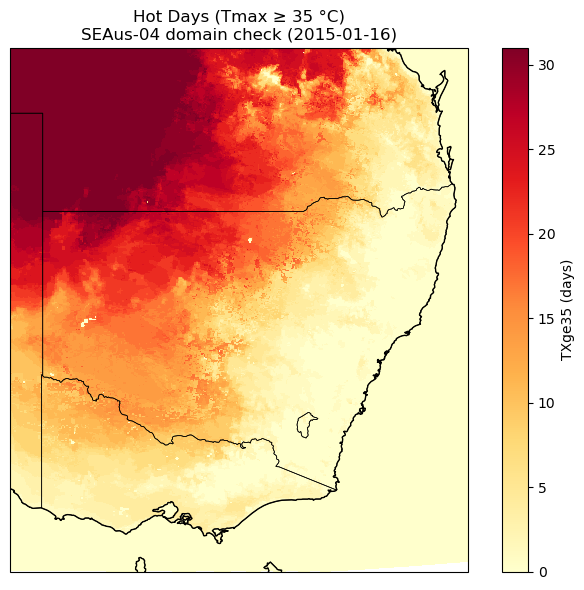

In [8]:
fig = plt.figure(figsize=(7, 6))
ax  = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(
    lon2d, lat2d, index_seas.isel(time=0),
    transform=ccrs.PlateCarree(), shading='auto', cmap='YlOrRd'
)
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label=f'{INDEX} (days)')
t0 = str(index_seas.time.values[0])[:10]
plt.title(f'{INDEX_LABEL[INDEX]}\nSEAus-04 domain check ({t0})')
plt.tight_layout()
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Climatologies and climate change signal

Since only future data (2015–2100) is available, we use:
- **Reference**: 2015–2044 (30-year near-term future)
- **Future**: 2070–2099 (30-year end-of-century)
- **Signal**: Future minus reference (units: Δ days/season)


In [9]:
# --- Step 1: Seasonal annual mean (one value per year per cell) ---
seas_annual = index_seas.groupby('season_year').mean('time')

# --- Step 2: Reference climatology (near-term future 2015-2044) ---
seas_ref = (
    seas_annual
    .sel(season_year=slice(REF_START, REF_END))
    .mean('season_year')
)

# --- Step 3: End-of-century climatology (2070-2099) ---
seas_fut = (
    seas_annual
    .sel(season_year=slice(FUT_START, FUT_END))
    .mean('season_year')
)

# --- Step 4: Climate change signal ---
seas_signal = seas_fut - seas_ref

valid = ~np.isnan(seas_ref.values)
print(f'{INDEX} ({INDEX_LABEL[INDEX]})')
print(f'  Reference  ({REF_START}-{REF_END}) domain mean : '
      f'{float(seas_ref.values[valid].mean()):.1f} days/season')
print(f'  Future     ({FUT_START}-{FUT_END}) domain mean : '
      f'{float(seas_fut.values[valid].mean()):.1f} days/season')
print(f'  Signal domain mean             : '
      f'{float(seas_signal.values[valid].mean()):.1f} days/season')


TXge35 (Hot Days (Tmax ≥ 35 °C))
  Reference  (2015-2044) domain mean : 12.8 days/season
  Future     (2070-2099) domain mean : 16.1 days/season
  Signal domain mean             : 3.3 days/season


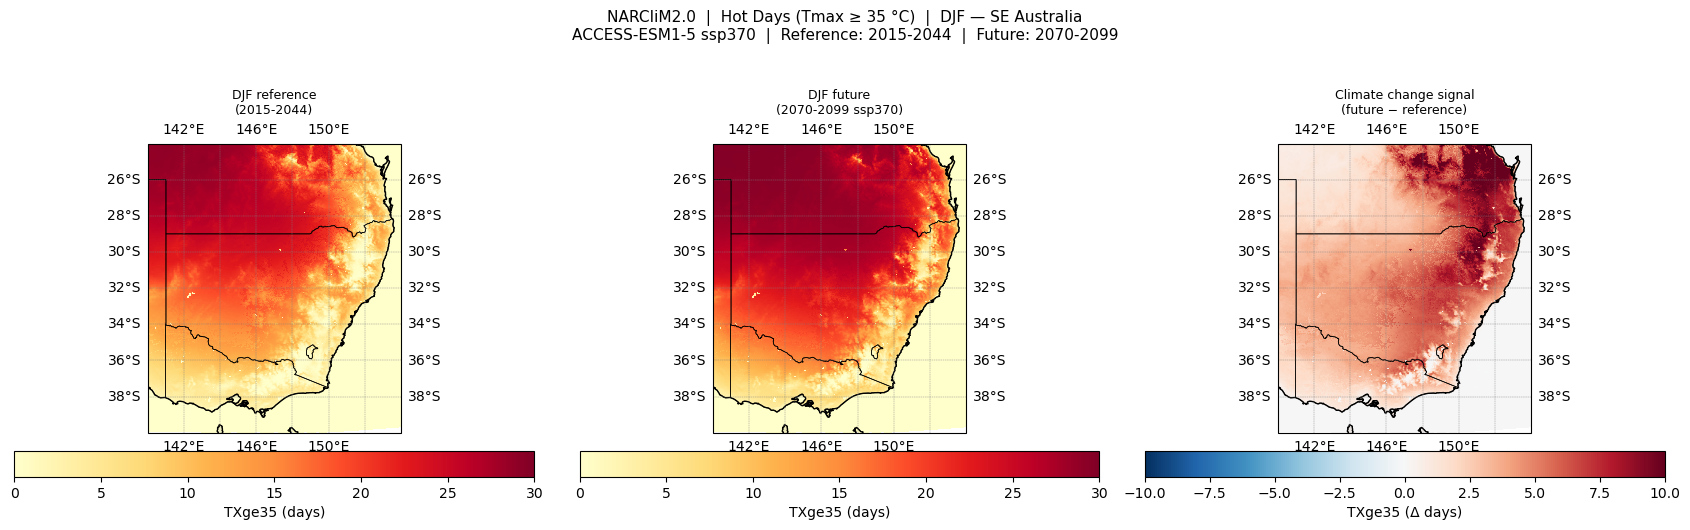

In [10]:
cmap_count  = 'YlOrRd'
cmap_signal = 'RdBu_r'

vmax_count = max(
    float(np.nanmax(seas_ref.values)),
    float(np.nanmax(seas_fut.values))
)
vmax_count = np.ceil(vmax_count / 10) * 10

sig_abs = float(np.nanpercentile(
    np.abs(seas_signal.values[~np.isnan(seas_signal.values)]), 95))
sig_lim = np.ceil(sig_abs / 5) * 5

fields = [
    (seas_ref,    f'{SEASON} reference\n({REF_START}-{REF_END})',         cmap_count,  0,        vmax_count, 'days'),
    (seas_fut,    f'{SEASON} future\n({FUT_START}-{FUT_END} {SCENARIO})', cmap_count,  0,        vmax_count, 'days'),
    (seas_signal, 'Climate change signal\n(future − reference)',           cmap_signal, -sig_lim, sig_lim,    'Δ days'),
]

fig, axes = plt.subplots(
    1, 3, figsize=(17, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, (field, title, cmap, vmin, vmax, unit) in zip(axes, fields):
    if cmap == cmap_signal:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        pcm = ax.pcolormesh(lon2d, lat2d, field,
                            transform=ccrs.PlateCarree(),
                            shading='auto', cmap=cmap, norm=norm)
    else:
        pcm = ax.pcolormesh(lon2d, lat2d, field,
                            transform=ccrs.PlateCarree(),
                            shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.3, color='grey', linestyle='--')
    ax.set_title(title, fontsize=9)
    plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05,
                 label=f'{INDEX} ({unit})')

plt.suptitle(
    f'NARCliM2.0  |  {INDEX_LABEL[INDEX]}  |  {SEASON} — SE Australia\n'
    f'ACCESS-ESM1-5 {SCENARIO}  |  '
    f'Reference: {REF_START}-{REF_END}  |  Future: {FUT_START}-{FUT_END}',
    y=1.03, fontsize=11
)
plt.tight_layout()
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Anomaly time series

For each season-year the anomaly relative to the near-term reference (2015–2044):

$$\Delta N_{\mathrm{season}}(y) = \bar{N}_{\mathrm{season}}(y) - \bar{N}_{\mathrm{ref}}$$

Spatially averaged over the domain to give one number per year.


In [11]:
# Domain-averaged seasonal annual mean
seas_ts = seas_annual.mean(dim=['rlat', 'rlon'])

# Reference mean (2015-2044)
ref_mean = float(
    seas_ts.sel(season_year=slice(REF_START, REF_END)).mean().values
)

# Anomaly
seas_anom = seas_ts - ref_mean
years = seas_anom['season_year'].values
anom  = seas_anom.values

print(f'Index : {INDEX}  ({INDEX_LABEL[INDEX]})')
print(f'Reference mean ({REF_START}-{REF_END}): {ref_mean:.1f} days/season')
print(f'Year range: {int(years.min())} - {int(years.max())}  ({len(years)} years)')


Index : TXge35  (Hot Days (Tmax ≥ 35 °C))
Reference mean (2015-2044): 12.8 days/season
Year range: 2015 - 2100  (86 years)


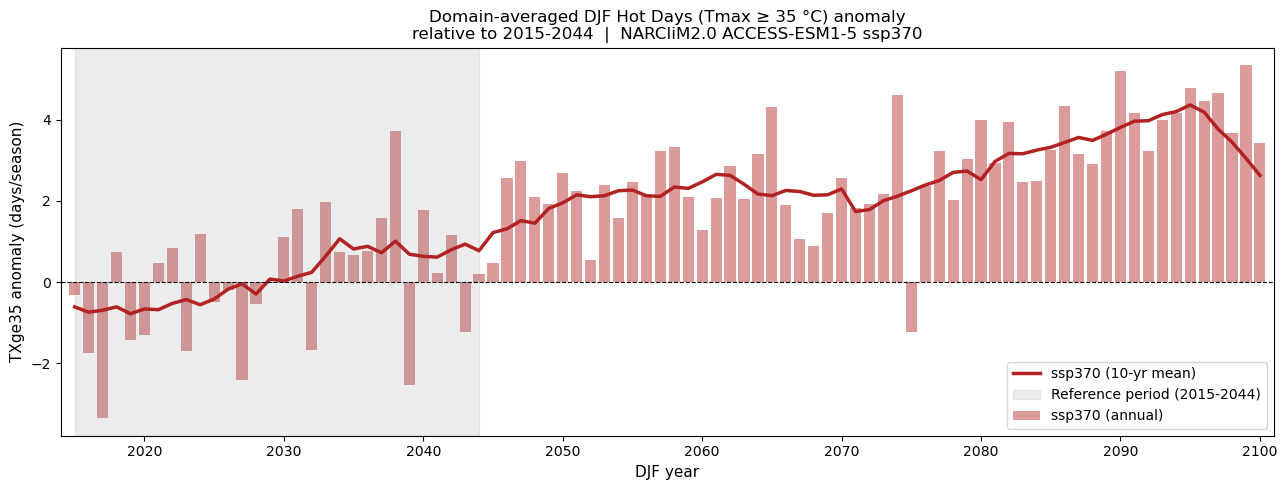

In [12]:
def running_mean(x, n=10):
    return np.convolve(x, np.ones(n) / n, mode='same')

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(years, anom, color='firebrick', alpha=0.45, label=f'{SCENARIO} (annual)')
ax.plot(years, running_mean(anom), color='firebrick', lw=2.5,
        label=f'{SCENARIO} (10-yr mean)')

ax.axvspan(REF_START, REF_END, color='grey', alpha=0.15,
           label=f'Reference period ({REF_START}-{REF_END})')
ax.axhline(0, color='black', lw=0.8, ls='--')

ax.set_xlim(DATA_START - 1, DATA_END + 1)
ax.set_xlabel(f'{SEASON} year', fontsize=11)
ax.set_ylabel(f'{INDEX} anomaly (days/season)', fontsize=11)
ax.set_title(
    f'Domain-averaged {SEASON} {INDEX_LABEL[INDEX]} anomaly\n'
    f'relative to {REF_START}-{REF_END}  |  NARCliM2.0 ACCESS-ESM1-5 {SCENARIO}',
    fontsize=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Seasonal climatology maps

Four-panel maps of mean seasonal count across DJF / MAM / JJA / SON,
computed over the **reference period (2015–2044)** from the loaded data.
No additional file loading is needed — we filter `index_seas` by month.


In [13]:
# Re-open the full dataset (all months) for the reference period
# We already have DJF-only in index_seas; for all-season maps we need
# to load all months from the same file for 2015-2044.
import time as _time

print(f'Loading all months ({DATA_START}-{DATA_END}) from same file ...')
ds_full = xr.open_dataset(DATA_URL)

# Apply domain mask and select reference period
domain_mask_2d = build_domain_mask(ds_full)
da_full = ds_full[INDEX].where(domain_mask_2d)

# Restrict to reference period
ref_time_mask = (
    (ds_full['time.year'] >= REF_START) &
    (ds_full['time.year'] <= REF_END)
)
index_ref_full = da_full.isel(time=ref_time_mask.values)
index_ref_full.load()
ds_full.close()

print(f'Done. Shape: {index_ref_full.shape}  '
      f'({REF_START}-{REF_END}, all months)')


Loading all months (2015-2100) from same file ...


RuntimeError: NetCDF: Authorization failure

In [39]:
# Seasonal climatology — mean count per season over the reference period
seasonal_clim = index_ref_full.groupby('time.season').mean('time')

# Seasonal anomaly relative to the cross-season mean
seasonal_anom = seasonal_clim - seasonal_clim.mean('season')

print('Seasons computed:', list(seasonal_clim.season.values))
print('Reference-period seasonal means (domain avg, days/season):')
for s in ['DJF', 'MAM', 'JJA', 'SON']:
    val = float(np.nanmean(seasonal_clim.sel(season=s).values))
    print(f'  {s}: {val:.1f}')


In [40]:
fig, axes = plt.subplots(
    2, 2, figsize=(10, 9),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True
)
axes = axes.flatten()

vmax_seas = float(np.nanpercentile(
    seasonal_clim.values[~np.isnan(seasonal_clim.values)], 98))
vmax_seas = np.ceil(vmax_seas / 10) * 10

for ax, s in zip(axes, ['DJF', 'MAM', 'JJA', 'SON']):
    pcm = ax.pcolormesh(
        lon2d, lat2d, seasonal_clim.sel(season=s),
        transform=ccrs.PlateCarree(),
        shading='auto', cmap='YlOrRd', vmin=0, vmax=vmax_seas
    )
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.3, color='grey', linestyle='--')
    ax.set_title(s, fontsize=11)

cbar = fig.colorbar(pcm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.06)
cbar.set_label(f'{INDEX} (days/season)', fontsize=11)

fig.suptitle(
    f'{INDEX_LABEL[INDEX]} — seasonal climatology — SE Australia\n'
    f'Reference: {REF_START}-{REF_END}  |  NARCliM2.0 ACCESS-ESM1-5',
    fontsize=13
)
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Regrid for GIS export

The native WRF rotated grid is regridded to a regular 0.04-degree lat/lon grid
(matching the NARCliM2-0-SEAus-04 nominal 4 km resolution) using **xESMF
bilinear regridding** for export to GIS platforms.


In [41]:
# 0.04° ≈ 4 km — matches SEAus-04 nominal resolution
lon_new = np.arange(LON_MIN, LON_MAX + 0.04, 0.04)
lat_new = np.arange(LAT_MIN, LAT_MAX + 0.04, 0.04)
ds_out  = xr.Dataset({'lat': (['lat'], lat_new), 'lon': (['lon'], lon_new)})

# Build regridder from the reference field
regridder = xe.Regridder(seas_ref, ds_out, method='bilinear', periodic=False)

seas_ref_ll    = regridder(seas_ref)
seas_fut_ll    = regridder(seas_fut)
seas_signal_ll = regridder(seas_signal)
seasonal_ll    = regridder(seasonal_clim)

print('Regridded shapes:')
print('  seas_signal_ll  :', seas_signal_ll.shape)
print('  seasonal_ll     :', seasonal_ll.shape)


In [42]:
sig_abs = float(np.nanpercentile(
    np.abs(seas_signal_ll.values[~np.isnan(seas_signal_ll.values)]), 95))
sig_lim = np.ceil(sig_abs / 5) * 5

norm = TwoSlopeNorm(vmin=-sig_lim, vcenter=0, vmax=sig_lim)
seas_signal_ll.plot(cmap='RdBu_r', norm=norm, figsize=(6, 7))
plt.xlim(LON_MIN, LON_MAX)
plt.ylim(LAT_MIN, LAT_MAX)
plt.title(
    f'{INDEX_LABEL[INDEX]} — climate change signal (regridded)\n'
    f'{FUT_START}-{FUT_END} ({SCENARIO}) minus {REF_START}-{REF_END}'
)
plt.tight_layout()
plt.show()


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Export products

Four NetCDF files are saved per index:

1. Reference climatology — seasonal mean count (regridded)
2. Future climatology — seasonal mean count (regridded)
3. Climate change signal — future minus reference (regridded)
4. Target-point (Sydney) time series — annual seasonal count (native grid)


In [43]:
output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

# 1-3: Regridded seasonal climatology fields
seas_ref_ll.to_netcdf(
    output_dir / f'{INDEX}_{SEASON}_ref_{REF_START}-{REF_END}_SEAus.nc')
seas_fut_ll.to_netcdf(
    output_dir / f'{INDEX}_{SEASON}_fut_{FUT_START}-{FUT_END}_{SCENARIO}_SEAus.nc')
seas_signal_ll.to_netcdf(
    output_dir / f'{INDEX}_{SEASON}_signal_{SCENARIO}_{FUT_START}-{FUT_END}'
                 f'_vs_{REF_START}-{REF_END}_SEAus.nc')

# 4: Target-point (Sydney) time series — DJF season-year values
rlat_idx, rlon_idx = nearest_point(index_seas, TARGET_LON, TARGET_LAT)
target_ts = index_seas.isel(rlat=rlat_idx, rlon=rlon_idx)
target_ts.to_netcdf(
    output_dir / f'{INDEX}_{SEASON}_{TARGET_LABEL.lower()}_{DATA_START}-{DATA_END}_{SCENARIO}.nc')

for f in sorted(output_dir.iterdir()):
    print('Exported:', f)


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Interpretation

### Data availability
This catalog provides only the **SSP3-7.0 future run (2015–2100)** as a
single file. No historical simulation (1951–2014) is available here.
The reference period is therefore the **near-term future (2015–2044)**
rather than the conventional 1980–2009 historical baseline.

### Climate change signal
The signal map shows the change in hot days per season between 2015–2044
and 2070–2099 under SSP3-7.0. Positive values (red) indicate more frequent
extreme heat at end-of-century.

### Anomaly time series
The rising trend from the early period toward 2100 reflects the SSP3-7.0
forced warming signal. Natural variability is superimposed on this trend.

### Seasonal climatology
For `TXge35`, DJF (austral summer) dominates; JJA values should be near
zero or zero across SE Australia.

### Switching indices
Change `INDEX` in the Configuration cell to any of `TX90p`, `TXgt50p`,
or `TX10p` — all confirmed present in this catalog.


This notebook implements a reproducible, memory-efficient workflow:

- **All parameters in one configuration cell** — change scenario, period, or region without touching analysis code.
- **Time chunking** — only DJF months are streamed from THREDDS, reducing download volume by ~75%.
- **Correct DJF convention** — December is assigned to the following year.
- **Correct anomaly definition** — DJF anomaly = DJF mean minus DJF climatology, not minus annual mean.
- **30-year averages** — robust climatologies that reduce the influence of interannual variability.


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>

## Next steps

- **Switch index**: change `INDEX` to `TX90p`, `TXgt50p`, or `TX10p`
  (all confirmed in catalog). Note `TXge40` does not exist.
- **Different reference period**: adjust `REF_START` / `REF_END` within 2015–2100.
- **Sub-region**: tighten `LON_MIN/MAX`, `LAT_MIN/MAX` (e.g. Greater Sydney, ACT).
- **Historical baseline**: if a companion historical file becomes available
  on THREDDS, add it as a second `DATA_URL_HIST` and concatenate before
  the analysis cells.
- **Other ensemble members**: check the catalog for additional `r*i1p1f1` runs
  once they are published.


<div style="text-align: right">
  <a href="#top">Go back to top</a>
</div>